In [1]:
import os
import sys

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
# import ipywidgets as widgets
from IPython.display import display

In [2]:
import os
import sys
project_src = os.path.abspath('../src')
if project_src not in sys.path:
    sys.path.insert(0, project_src)

# Get the absolute path to the project root (one directory up from 'notebooks')
# Add it to sys.path if not already there

from value_at_risk.data.market import read_data
from value_at_risk.evaluation.backtest_value_at_risk import *

from value_at_risk.utils.clean_data import *
from value_at_risk.utils.plot_utils import *
from value_at_risk.utils.save_data import *

from value_at_risk.utils.var_functional_analysis import print_analysis_summary, plot_3d_surface_v2
from value_at_risk.utils.var_widgets import display_var_widgets

from value_at_risk.models.deep_var.features import *
from value_at_risk.models.deep_var.lstm_model import *
from value_at_risk.models.deep_var.parametric_model import *

os.makedirs('../outputs/plots', exist_ok=True) # Ensure directory exists
os.makedirs('../outputs/metrics', exist_ok=True)

In [ ]:
tickers = { "^GSPC": "S&P 500",
    "BTC-USD": "Bitcoin",
    "CLP=X": "USD/CLP (Chile Peso)",
    "SQM": "SQM (Lithium)",
    "HG=F": "Copper Futures",
    "TSLA": "Tesla",
    "NVDA": "NVIDIA",
    "CL=F": "Crude Oil",
    # "TLT": "US Treasuries (20Y)",
    # "VXX": "VIX Volatility"
    }
    

In [24]:
alpha_widget = 0.01 
rolling_widget = 132
epochs_widget = 20000
lr_widget = 0.02
ticker_widget, date_widget = "CL=F", "2026-06-30"

# # Display additional parameter widgets
# print("\n")
# display(alpha_widget)
# display(rolling_widget)
# display(epochs_widget)
# display(lr_widget)

In [25]:
# === APPLY WIDGET SELECTIONS ===
# Extract values from widgets
# TICKER = ticker_widget.value
# DATE_REPORT = date_widget.value.strftime('%Y-%m-%d')
# ALPHA = alpha_widget.value
# ROLLING_WINDOW = rolling_widget.value
# EPOCHS = epochs_widget.value
# LEARNING_RATE = lr_widget.value

TICKER = ticker_widget
DATE_REPORT = date_widget

ALPHA = alpha_widget
ROLLING_WINDOW = rolling_widget
EPOCHS = epochs_widget
LEARNING_RATE = lr_widget

# Fixed parameters
MARKET_DATA_SOURCE = 'yfinance'
WEIGHT_PRIOR = 1.0

# Display current configuration
print("="*60)
print("CURRENT CONFIGURATION")
print("="*60)
print(f"Ticker:          {TICKER} ({tickers.get(TICKER, 'Unknown')})")
print(f"Report Date:     {DATE_REPORT}")
print(f"Risk Level:      {ALPHA*100}% VaR (α={ALPHA})")
print(f"Rolling Window:  {ROLLING_WINDOW} days")
print(f"Epochs:          {EPOCHS}")
print(f"Learning Rate:   {LEARNING_RATE}")
print(f"Prior Weight:    {WEIGHT_PRIOR}")
print("="*60)

CURRENT CONFIGURATION
Ticker:          CL=F (Crude Oil)
Report Date:     2026-06-30
Risk Level:      1.0% VaR (α=0.01)
Rolling Window:  132 days
Epochs:          20000
Learning Rate:   0.02
Prior Weight:    1.0


In [26]:
# Load data
print(f"Loading data for {TICKER}...")
df = read_data(TICKER, market_data_source=MARKET_DATA_SOURCE, end_date=DATE_REPORT)
print(f"✓ Loaded {len(df)} observations")
print(f"  Date range: {df.index[0]} to {df.index[-1]}")

Loading data for CL=F...
✓ Loaded 2512 observations
  Date range: 2016-06-30 00:00:00 to 2026-06-29 00:00:00


,price
Date,
2016-06-30,48.330002
2016-07-01,48.990002
2016-07-05,46.599998
2016-07-06,47.430000
2016-07-07,45.139999


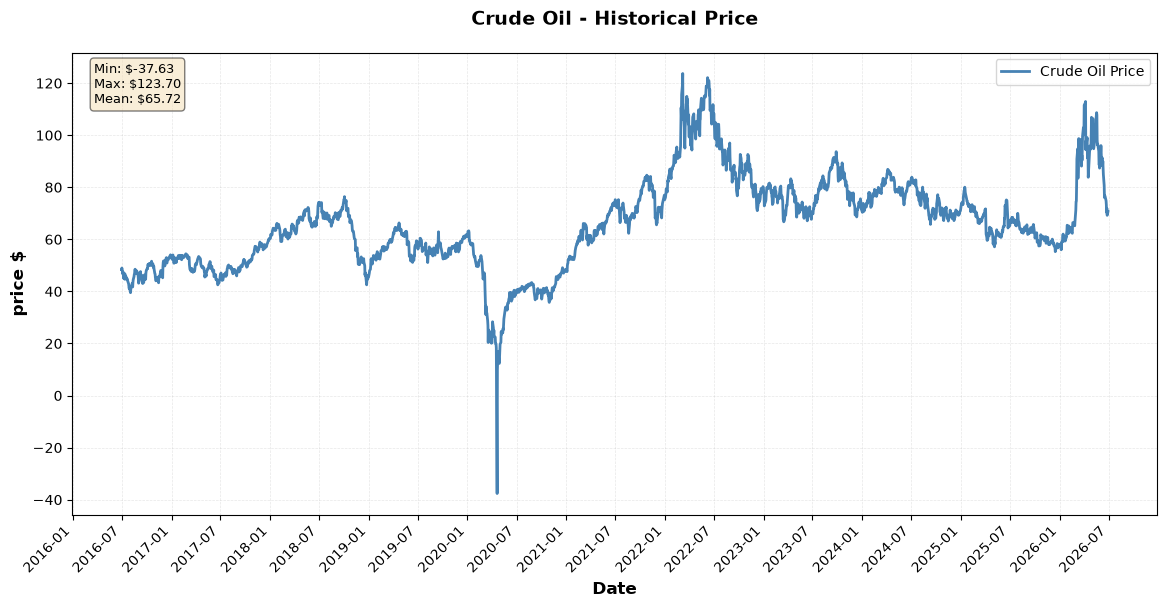

In [27]:
improved_price_plot(df, tickers[TICKER])

# Display sample
df.head()

⚠️ Found 3 outliers. Smoothing...
⚠️ Found and smoothed 3 outliers


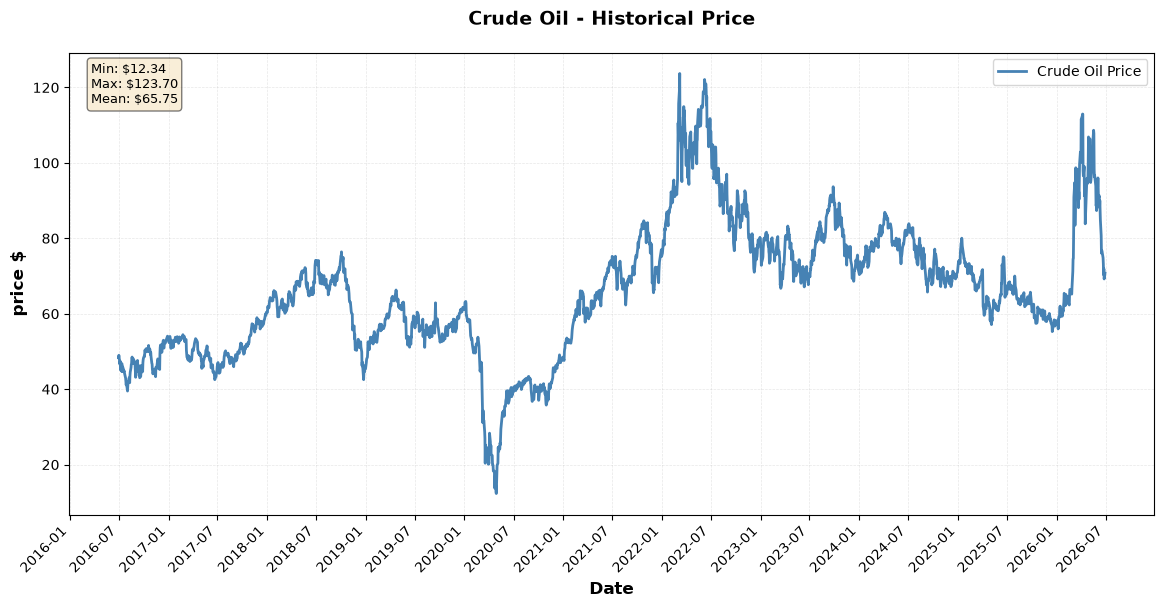

In [28]:
# Clean data
df, n_outliers = clean_data(df, z_score_threshold=8)
if n_outliers > 0:
    print(f"⚠️ Found and smoothed {n_outliers} outliers")
    improved_price_plot(df, tickers[TICKER])
else:
    print("✓ No outliers detected")

In [29]:
# Basic statistics
print(f"Data points: {len(df)}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nPrice statistics:")
print(df['price'].describe())

# Calculate returns
returns = df['price'].pct_change().dropna()
print(f"\nReturn statistics:")
print(returns.describe())
print(f"Skewness: {returns.skew():.3f}")
print(f"Kurtosis: {returns.kurtosis():.3f}")

Data points: 2512
Date range: 2016-06-30 00:00:00 to 2026-06-29 00:00:00

Price statistics:
count    2512.000000
mean       65.751413
std        17.325580
min        12.340000
25%        53.330002
50%        65.264999
75%        76.082500
max       123.699997
Name: price, dtype: float64

Return statistics:
count    2511.000000
mean        0.000560
std         0.028466
min        -0.245882
25%        -0.012461
50%         0.002058
75%         0.013870
max         0.250996
Name: price, dtype: float64
Skewness: -0.019
Kurtosis: 19.509


In [30]:
percentage_train = 0.7

train_int = int(len(df) * percentage_train)
split_date = df.index[train_int]
split_date

Timestamp('2023-06-29 00:00:00')

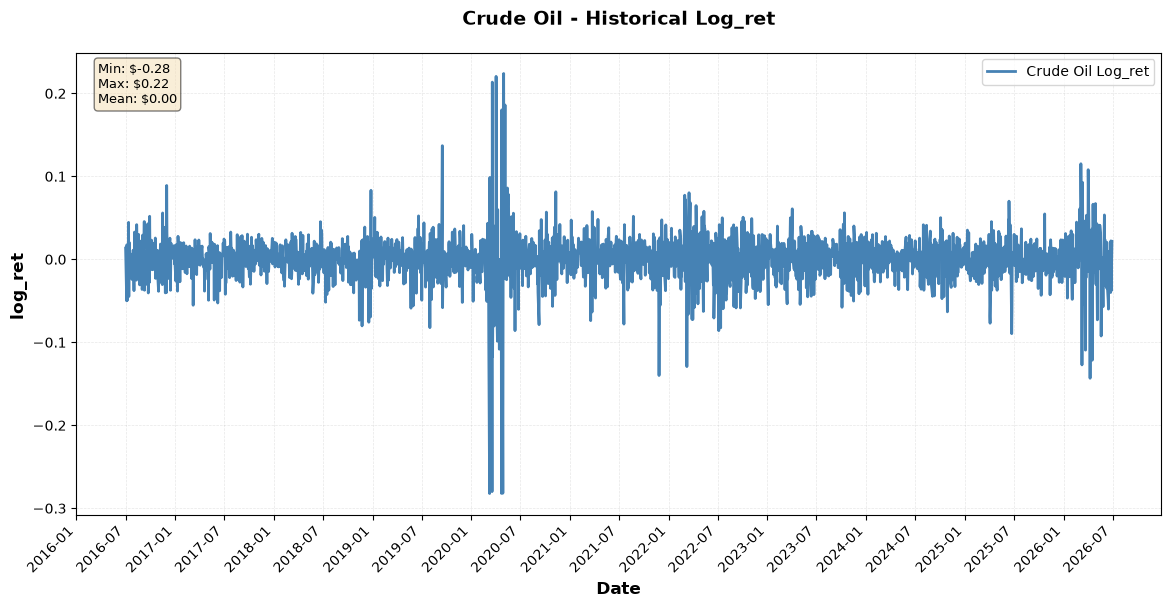

In [31]:
df['log_ret'] = np.log(df['price'] / df['price'].shift(1))
df.dropna(inplace=True)
improved_price_plot(df, tickers[TICKER], column='log_ret')

In [32]:
models_results = {}

In [33]:
def print_parameters(TICKER, ALPHA, split_date, ROLLING_WINDOW):
    # Train model
    print(f"\n{'='*60}")
    print(f"Training VaR Model - {TICKER}")
    print(f"{'='*60}")
    print(f"Risk Level (α): {ALPHA*100}%")
    print(f"Training until: {split_date}")
    print(f"Rolling window: {ROLLING_WINDOW} days")
    print(f"{'='*60}\n")
    return


In [34]:
## check the function

In [35]:
attempt_name = "Neural Network"
features = ['log_ret']
data = create_features(df, ALPHA, ROLLING_WINDOW, features=features)

print_parameters(TICKER, ALPHA, split_date, ROLLING_WINDOW)

split_type={'percentage': percentage_train}

model, history, train_data, test_data = train_model(
    data, 
    model_type='QuantileLSTM', 
    alpha=ALPHA, 
    epochs=EPOCHS, 
    lr=LEARNING_RATE, 
    rolling=ROLLING_WINDOW, 
    split_type=split_type,
    silent=True,
    regularization_pm=None
)

print(f"\n✓ Training complete!")
print(f"  Final train loss: {history['train_loss'][-1]:.5f}")
print(f"  Final test loss: {history['test_loss'][-1]:.5f}")


Training VaR Model - CL=F
Risk Level (α): 1.0%
Training until: 2023-06-29 00:00:00
Rolling window: 132 days

--- 🧠 Training QuantileLSTM (alpha=0.01) ---

✓ Training complete!
  Final train loss: 0.00141
  Final test loss: 0.00106


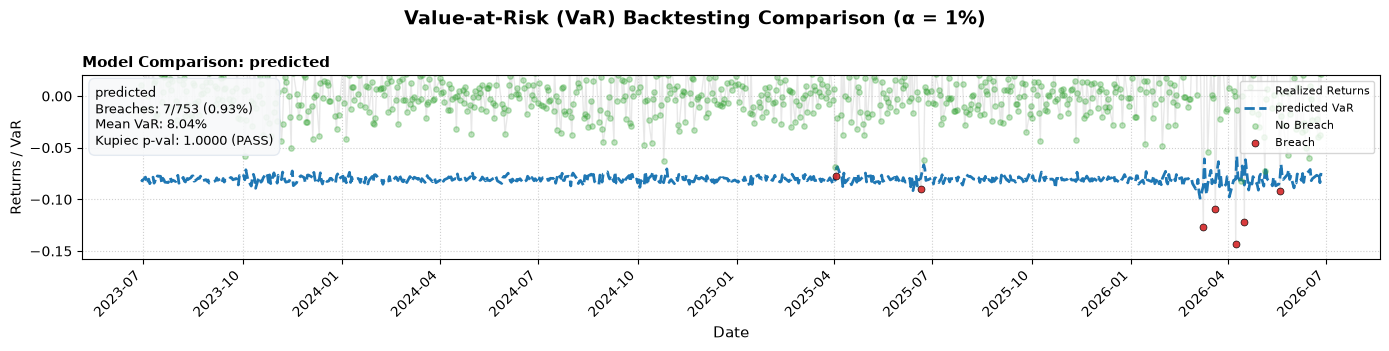

In [36]:
df_results = reestructure_testdata(test_data)
models_results[attempt_name] = df_results

plot_var_results(df_results)


### Garch

Calculating GARCH(1,1) Baseline VaR...
GARCH calculation complete.


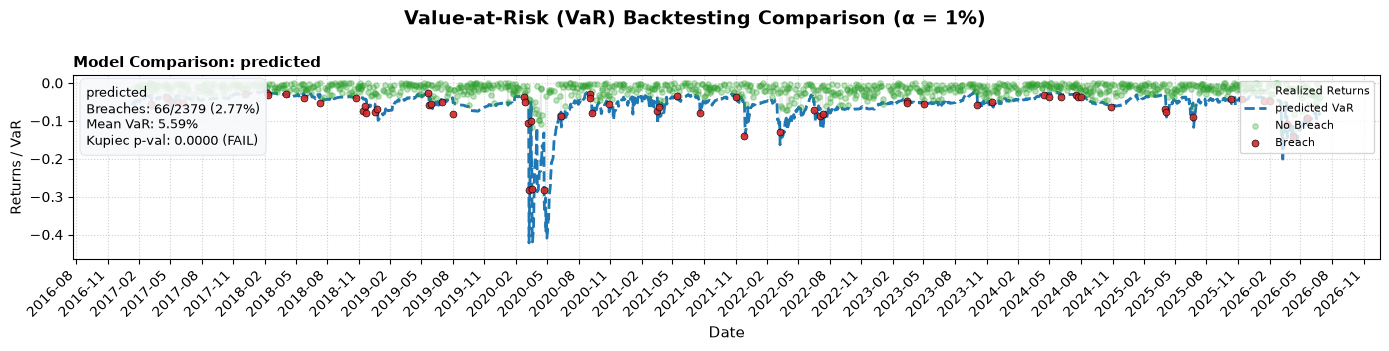

In [37]:
from value_at_risk.models.garch_model import calculate_garch_var
# df_results = pd.DataFrame([])
print('Calculating GARCH(1,1) Baseline VaR...')
garch_column = 'GARCH(1,1)'
# The function expects unscaled returns, we pass df['log_ret'] which is unscaled
garch_var = calculate_garch_var(df['log_ret'], window=ROLLING_WINDOW, alpha=ALPHA).dropna()
print('GARCH calculation complete.')

df_results_garch = pd.Series(garch_var, name='predicted')
df_results_garch = pd.concat([df['log_ret'], df_results_garch], axis=1)
df_results_garch.columns = ['realized', 'predicted']
df_results_garch.dropna(inplace=True)

models_results[garch_column] = df_results_garch
df_results_garch.loc[df_results_garch['realized'] >= 0, 'realized'] = np.nan

plot_var_results(df_results_garch)

## Anchor NN

In [38]:
attempt_name = "Anchor NN"
regularization_pm = {'weight': 0.005}

scale_factor = 100
df_scaled = df.copy()
df_scaled['log_ret'] = df_scaled['log_ret'] * scale_factor

regularization_pm['df'] = df_scaled

features = ['log_ret', 'std', 'log_ret^2']
data_anchor = create_features(df_scaled, ALPHA, ROLLING_WINDOW, features=features)


In [39]:
# We use the SimpleQuantileNeuron now
model, history, _, test_data = train_model(
    data_anchor, 
    model_type='SimpleQuantileNeuron', 
    alpha=ALPHA, 
    epochs=EPOCHS, 
    lr=LEARNING_RATE, 
    rolling=ROLLING_WINDOW,
    split_type={'date': split_date},
    # pretrained_state_dict=model_walk_forward.state_dict(),
    regularization_pm=regularization_pm
)

print("Training Complete.")

--- 🧠 Training SimpleQuantileNeuron (alpha=0.01) ---
    Train size: 1627 | Test size: 22
Early stopping at epoch 563
    Train size: 1649 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 75
    Train size: 1671 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1693 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 271
    Train size: 1715 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 364
    Train size: 1737 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1759 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 4204
    Train size: 1781 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1803 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 61
    Train size: 1825 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch

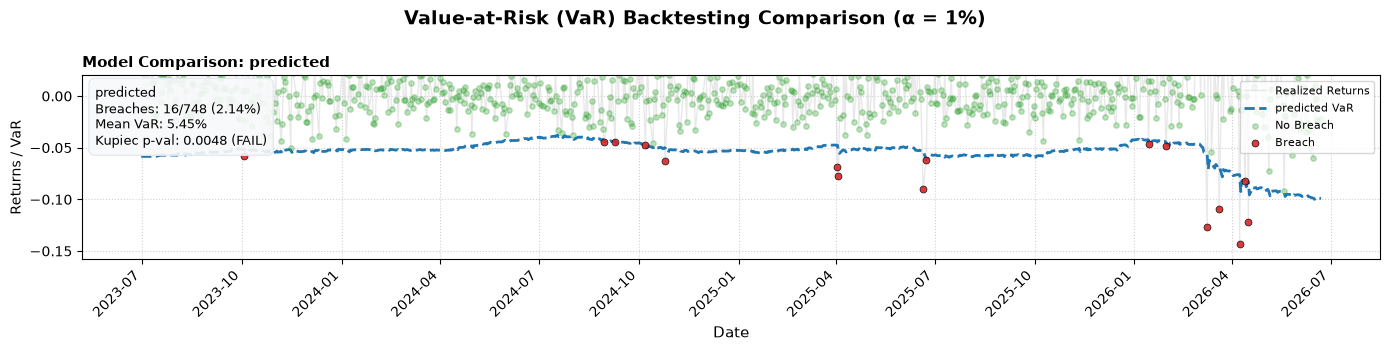

In [40]:
df_results = reestructure_testdata(test_data) / scale_factor
models_results[attempt_name] = df_results

plot_var_results(df_results)

## Anchor Hist NN


In [38]:
attempt_name = "Anchor Hist NN"
regularization_pm = {'weight': 0.05, 'type': 'hist'}

scale_factor = 100
df_scaled = df.copy()
df_scaled['log_ret'] = df_scaled['log_ret'] * scale_factor

regularization_pm['df'] = df_scaled

features = ['log_ret', 'std', 'log_ret^2']
data_anchor_hist = create_features(df_scaled, ALPHA, ROLLING_WINDOW, features=features)


In [39]:
# We use the SimpleQuantileNeuron now
model_hist, history_hist, _, test_data_hist = train_model(
    data_anchor_hist, 
    model_type='SimpleQuantileNeuron', 
    alpha=ALPHA, 
    epochs=EPOCHS, 
    lr=LEARNING_RATE, 
    rolling=ROLLING_WINDOW,
    split_type={'date': split_date},
    # pretrained_state_dict=model_walk_forward.state_dict(),
    regularization_pm=regularization_pm
)

print("Training Complete.")

--- 🧠 Training SimpleQuantileNeuron (alpha=0.01) ---
    Train size: 1627 | Test size: 22
Early stopping at epoch 563
    Train size: 1649 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 75
    Train size: 1671 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1693 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 271
    Train size: 1715 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 364
    Train size: 1737 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1759 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 4204
    Train size: 1781 | Test size: 22
--> Loaded pretrained weights (Warm Start)
    Train size: 1803 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch 61
    Train size: 1825 | Test size: 22
--> Loaded pretrained weights (Warm Start)
Early stopping at epoch

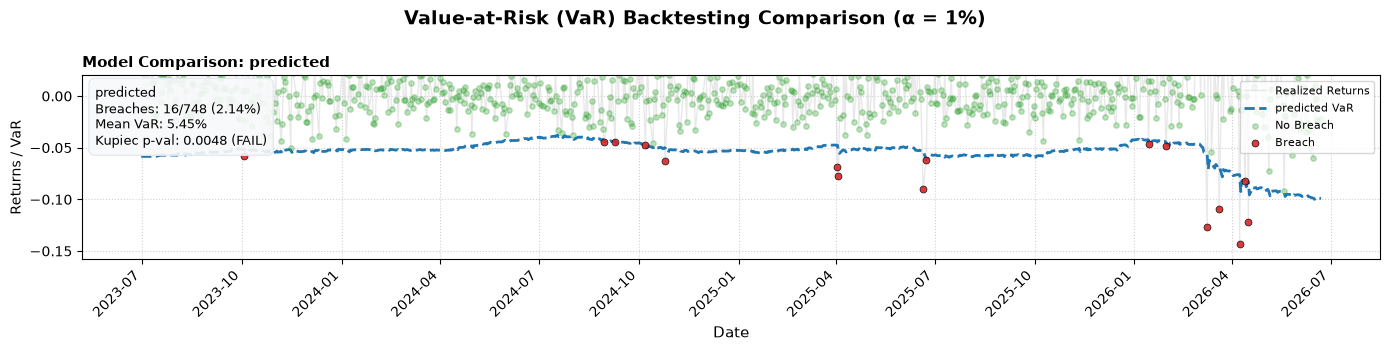

In [40]:
df_results = reestructure_testdata(test_data_hist) / scale_factor
models_results[attempt_name] = df_results

plot_var_results(df_results)

In [41]:
df_results = pd.DataFrame()
for model, df_result in models_results.items():
    df_result_aux = df_result[['predicted']].copy()
    df_result_aux.columns = [model]
    df_result_aux.index = df_result_aux.index.get_level_values(0)

    df_result_aux.index = pd.to_datetime(df_result_aux.index)

    df_results = pd.concat([df_results, df_result_aux], axis=1)


df_result_aux = df_result[['realized']]
df_result_aux.index = df_result_aux.index.get_level_values(0)
df_result_aux.index = pd.to_datetime(df_result_aux.index)
df_results = pd.concat([df_results, df_result_aux], axis=1)

df_hist_var = df.copy()
column = 'Historical VaR'
df_hist_var[column] = df_hist_var['log_ret'].rolling(252).quantile(0.01)
df_hist_var[column] = df_hist_var[column].shift(1)
df_hist_var.index = pd.to_datetime(df_hist_var.index)
df_results = pd.concat([df_results, df_hist_var[column]], axis=1)

df_results.dropna(inplace=True)

# df_results = pd.concat([df_results, df_result[['realized']]], axis=1)
# df_results.index = pd.to_datetime(df_results.index.get_level_values(0))


C:\Users\fe_ma\AppData\Local\Temp\ipykernel_22832\929741248.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_results = pd.concat([df_results, df_result_aux], axis=1)
C:\Users\fe_ma\AppData\Local\Temp\ipykernel_22832\929741248.py:22: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_results = pd.concat([df_results, df_hist_var[column]], axis=1)


TODO: Agregar tambien el maximo del capital requerido

In [42]:
def calculate_metrics(df, alpha=0.01):
    """
    Generates a comparative table of VaR models including Christoffersen.
    """
    metrics = []
    model_cols = [c for c in df.columns if c not in ['realized', 'date']]
    for col in model_cols:
        breaches = df[df['realized'] < df[col]]
        n_breaches = len(breaches)
        n_total = len(df)
        breach_rate = n_breaches / n_total
        
        try:
            kupiec_p = stats.binomtest(n_breaches, n_total, alpha, alternative='two-sided').pvalue
        except AttributeError:
            kupiec_p = 0.0
            
        b_series = (df['realized'] < df[col]).astype(int)
        n00 = n01 = n10 = n11 = 0
        for i in range(len(b_series) - 1):
            if b_series.iloc[i] == 0 and b_series.iloc[i+1] == 0: n00 += 1
            elif b_series.iloc[i] == 0 and b_series.iloc[i+1] == 1: n01 += 1
            elif b_series.iloc[i] == 1 and b_series.iloc[i+1] == 0: n10 += 1
            elif b_series.iloc[i] == 1 and b_series.iloc[i+1] == 1: n11 += 1
            
        p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
        p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
        p = (n01 + n11) / (n00 + n01 + n10 + n11) if (n00 + n01 + n10 + n11) > 0 else 0
        
        if p01 == 0 or p01 == 1 or p11 == 0 or p11 == 1 or p == 0 or p == 1:
            ind_stat = np.inf if p01 != p11 else 0
        else:
            ind_stat = -2 * (np.log((1-p)**(n00+n10) * p**(n01+n11)) - np.log((1-p01)**n00 * p01**n01 * (1-p11)**n10 * p11**n11))
        
        ind_pvalue = 1 - stats.chi2.cdf(ind_stat, df=1) if ind_stat != np.inf else 0.0
        
        avg_var = df[col].mean()
        max_var = df[col].min()
        min_var = df[col].max()
        responsiveness = df[col].std()
        
        metrics.append({
            'Model': col,
            'Breach Rate (%)': f"{breach_rate*100:.2f}%",
            'Kupiec p-value': f"{kupiec_p:.4f}",
            'Christoff p-value': f"{ind_pvalue:.4f}",
            'Avg Capital Reserved': f"{avg_var*100:.2f}%",
            'Max Capital Reserved': f"{max_var*100:.2f}%",
            'Min Capital Reserved': f"{min_var*100:.2f}%",
            'Responsiveness (Std)': f"{responsiveness:.4f}",
            'Status': "✅ PASS" if kupiec_p > 0.05 and abs(breach_rate - alpha) < 0.01 else "❌ FAIL"
        })
    return pd.DataFrame(metrics).set_index('Model')

summary_table = calculate_metrics(df_results.dropna())
print("\n=== 🏆 FINAL MODEL SHOWDOWN ===")
display(summary_table)



=== 🏆 FINAL MODEL SHOWDOWN ===


,Breach Rate (%),Kupiec p-value,Avg Capital Reserved,Max Capital Reserved,Min Capital Reserved,Responsiveness (Std),Status
Model,,,,,,,
Neural Network,0.94%,1.0000,-8.04%,-9.89%,-5.84%,0.0038,✅ PASS
"GARCH(1,1)",2.81%,0.0000,-5.12%,-20.08%,-2.12%,0.0249,❌ FAIL
Anchor NN,2.14%,0.0048,-5.45%,-10.00%,-3.77%,0.0120,❌ FAIL
Historical VaR,1.74%,0.0613,-5.83%,-11.54%,-4.28%,0.0174,✅ PASS


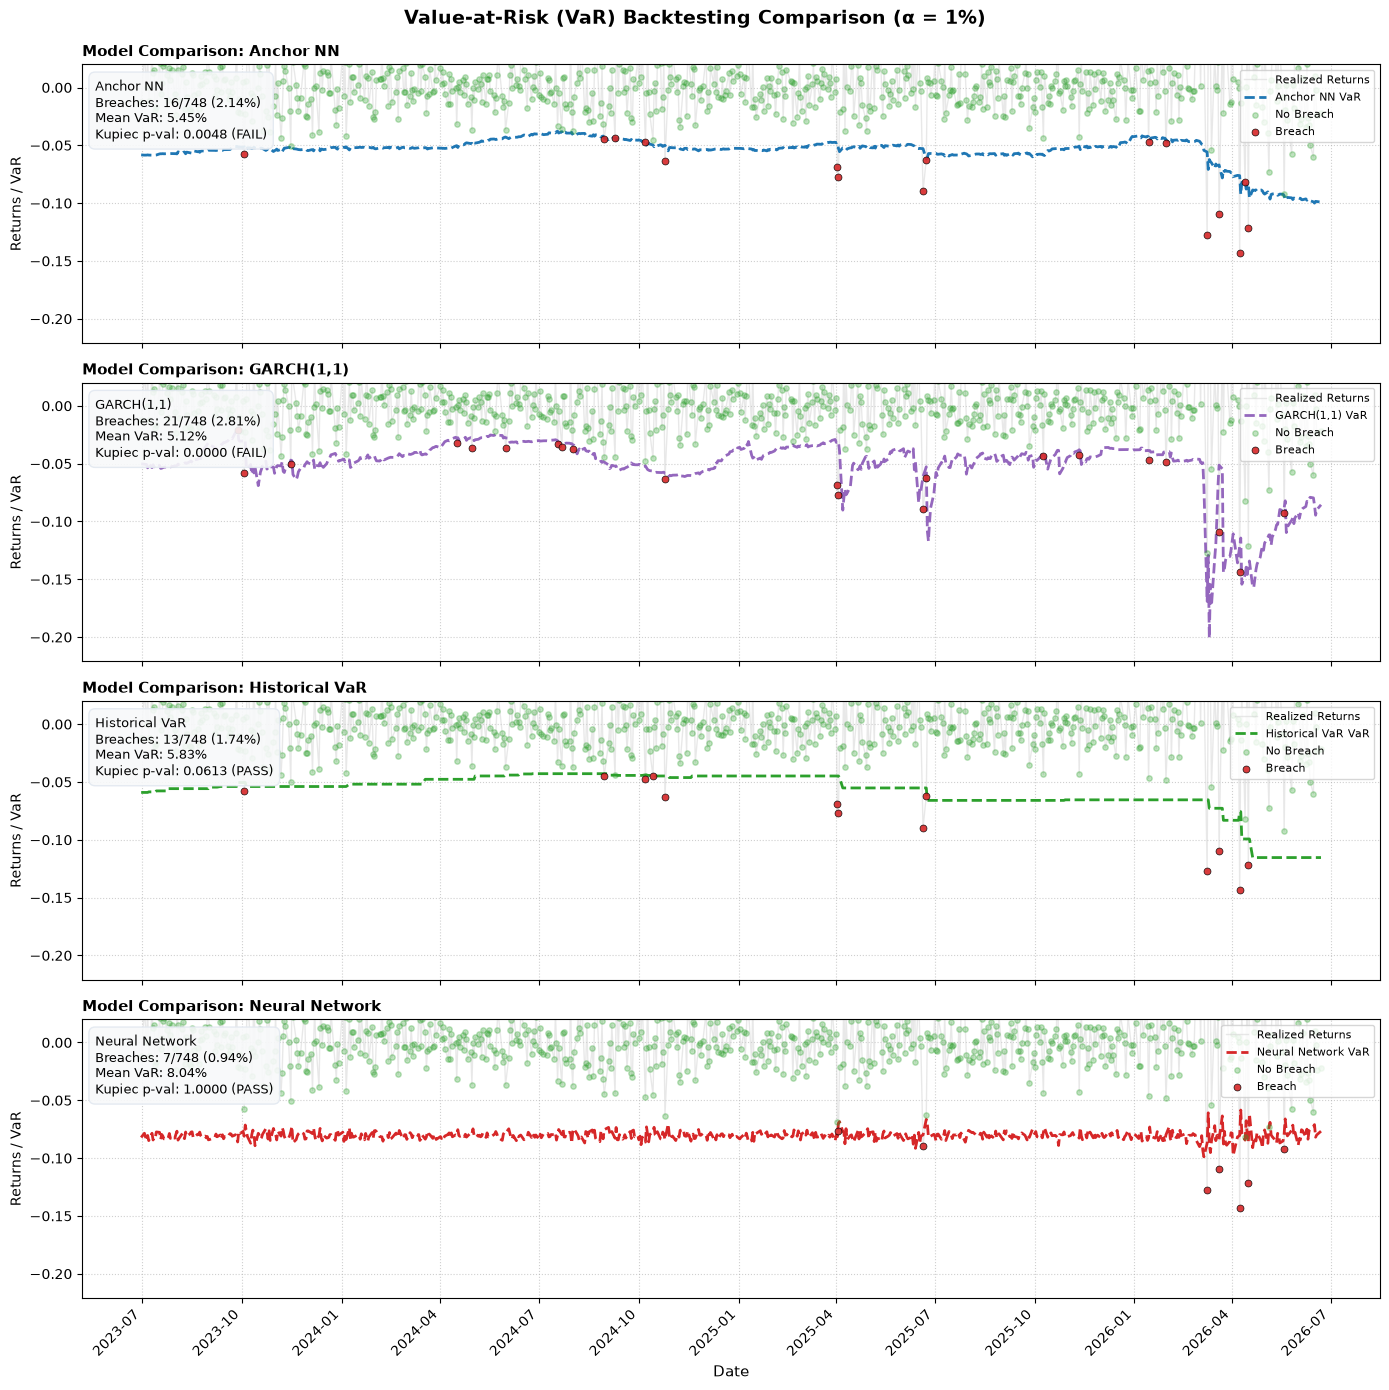

In [43]:
model_1 = 'Neural Network'
model_4 = 'Anchor NN'
model_6 = 'Historical VaR'
model_7 = 'GARCH(1,1)'

plot_var_results(df_results.dropna(), models={model_1, model_4, model_6, model_7}, file_name='compare_results.png')
